=== RESULTADO DEL ALGORITMO GENÉTICO ===
Mejor valor encontrado: 36.9096
x = 4.0897
y = 11.7257
Generación donde se encontró: 707


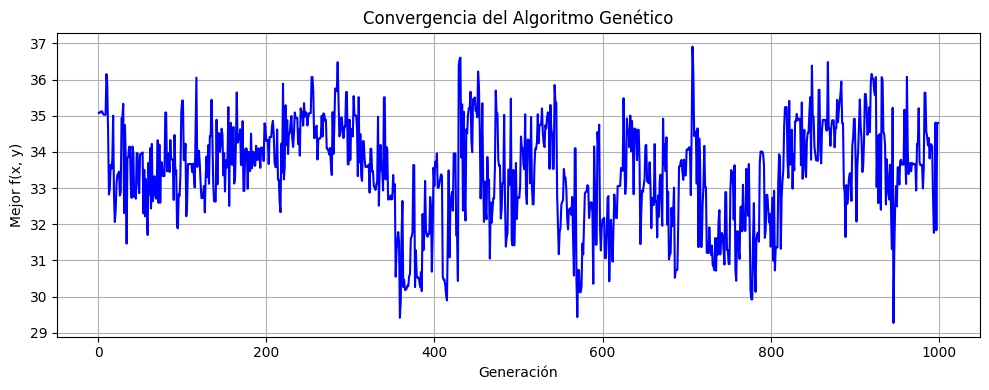

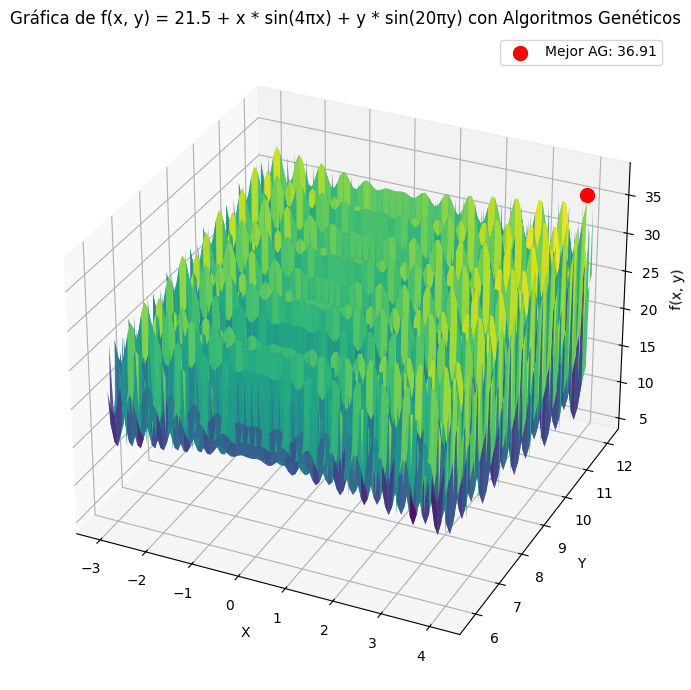

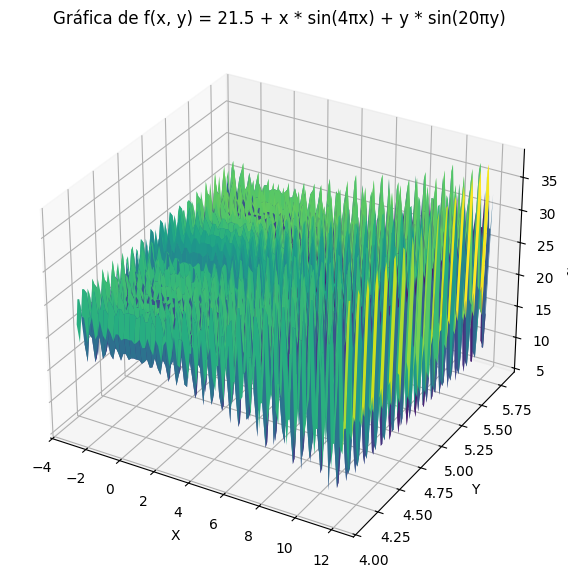

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# FUNCIONES DEL ALGORITMO GENÉTICO
def creapob(Nind, Lind):
    return np.random.randint(0, 2, size=(Nind, Lind))


def decodifica(genotipo, rango):
    Nvar = rango.shape[1]
    Nind, Lind = genotipo.shape
    Lvar = Lind // Nvar
    potencias = 2 ** np.arange(Lvar)
    fenotipo = np.zeros((Nind, Nvar))

    for i in range(Nind):
        for j in range(Nvar):
            fenotipo[i, j] = np.sum(potencias * genotipo[i, (j * Lvar):(j * Lvar + Lvar)])

    for i in range(Nvar):
        fenotipo[:, i] = rango[i, 0] + ((rango[i, 1] - rango[i, 0]) / (2 ** Lvar - 1)) * fenotipo[:, i]

    return fenotipo


def objfun(fenotipo):
    Nind, Nvar = fenotipo.shape
    objv = np.zeros((Nind, 1))

    for i in range(Nind):
        objv[i, 0] = 21.5 + fenotipo[i, 0] * np.sin(4 * np.pi * fenotipo[i, 0]) + fenotipo[i, 1] * np.sin(20 * np.pi * fenotipo[i, 1])

    return objv


def rankeo(objv, direccion):
    SP = 2
    Nind, Nobj = objv.shape
    aptitud = np.zeros((Nind, 1))

    if direccion == 1:
        nuevo_objv = np.sort(objv, axis=0)
    else:
        nuevo_objv = np.sort(-1 * objv, axis=0)

    apt = 2 - SP + 2 * (SP - 1) * (np.arange(Nind) / (Nind - 1))
    posori = np.argsort(nuevo_objv, axis=0)

    aptitud[posori, 0] = apt.reshape(-1, 1)

    return aptitud


def ruleta(genotipo, fenotipo, aptitud):
    Nind, aux = aptitud.shape
    total = np.sum(aptitud)
    probabilidad = aptitud / total
    acumulada = np.cumsum(probabilidad)
    idx = np.zeros((Nind, 1), dtype=int)

    for i in range(Nind):
        selecciona = np.random.rand()
        aux = np.where(acumulada >= selecciona)[0]
        idx[i, 0] = aux[0]

    nuevo_gen = genotipo[idx.flatten(), :]

    return nuevo_gen


def xunpunto(nuevo_gen, Pc):
    Nind, Lind = nuevo_gen.shape
    aux_gen = np.zeros((Nind, Lind))
    par = Nind % 2

    for i in range(0, Nind - 1, 2):
        cruza = np.random.rand()
        if cruza <= Pc:
            corte = np.random.randint(0, Lind - 1)
            aux_gen[i, :] = np.concatenate((nuevo_gen[i, :corte], nuevo_gen[i + 1, corte:]))
            aux_gen[i + 1, :] = np.concatenate((nuevo_gen[i + 1, :corte], nuevo_gen[i, corte:]))
        else:
            aux_gen[i, :] = nuevo_gen[i, :]
            aux_gen[i + 1, :] = nuevo_gen[i + 1, :]

    if par == 1:
        aux_gen[Nind - 1, :] = nuevo_gen[Nind - 1, :]

    nuevo_gen = aux_gen

    return nuevo_gen


def muta(nuevo_gen, Pm):
    Nind, Lind = nuevo_gen.shape
    valores = np.random.rand(Nind, Lind)
    muta = valores <= Pm
    nuevo_gen = np.logical_xor(nuevo_gen, muta)

    return nuevo_gen


# PARÁMETROS DEL ALGORITMO GENÉTICO
Nind = 100
Lind = 33
Pc = 0.9
Pm = 0.01
Maxgen = 1000
Nvar = 2
rango = np.array([[-3, 4.1], [12.1, 5.8]])

# POBLACIÓN INICIAL

genotipo = creapob(Nind, Lind)
fenotipo = decodifica(genotipo, rango)
generaciones = 1

# ALMACENAMIENTO DE MEJORES SOLUCIONES

Mejor = np.full((Maxgen, 1), np.nan)
Mejor_cromosoma = np.zeros((Maxgen, Lind))
objv = objfun(fenotipo)

# CICLO EVOLUTIVO

generaciones = 1

while generaciones < Maxgen:
    aptitud = rankeo(objv, 1)
    nuevo_gen = ruleta(genotipo, fenotipo, aptitud)
    nuevo_gen = xunpunto(nuevo_gen, Pc)
    nuevo_gen = muta(nuevo_gen, Pm)
    nuevo_feno = decodifica(nuevo_gen, rango)
    nuevo_objv = objfun(nuevo_feno)
    genotipo = nuevo_gen
    objv = nuevo_objv

    idx = np.argmax(objv)
    Mejor[generaciones] = objv[idx]
    Mejor_cromosoma[generaciones, :] = genotipo[idx, :]

    generaciones += 1

# RESULTADOS

mejor_idx = np.nanargmax(Mejor)
mejor_valor = Mejor[mejor_idx][0]
mejor_cromosoma = Mejor_cromosoma[mejor_idx, :]
mejor_fenotipo = decodifica(mejor_cromosoma.reshape(1, -1), rango)

print("=== RESULTADO DEL ALGORITMO GENÉTICO ===")
print(f"Mejor valor encontrado: {mejor_valor:.4f}")
print(f"x = {mejor_fenotipo[0, 0]:.4f}")
print(f"y = {mejor_fenotipo[0, 1]:.4f}")
print(f"Generación donde se encontró: {mejor_idx}")

# GRÁFICA DE CONVERGENCIA DEL AG

plt.figure(figsize=(10, 4))
plt.plot(Mejor, color='blue')
plt.xlabel('Generación')
plt.ylabel('Mejor f(x, y)')
plt.title('Convergencia del Algoritmo Genético')
plt.grid(True)
plt.tight_layout()
plt.show()

# GRÁFICA 3D DE LA FUNCIÓN (programación estructurada)

def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x = np.linspace(-3, 4.1, 100)
y = np.linspace(12.1, 5.8, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) = 21.5 + x * sin(4πx) + y * sin(20πy) con Algoritmos Genéticos')

# Marcar el mejor punto encontrado por el AG
ax.scatter(mejor_fenotipo[0, 0], mejor_fenotipo[0, 1], mejor_valor,
           color='red', s=100, zorder=5, label=f'Mejor AG: {mejor_valor:.2f}')
ax.view_init(elev=30, azim=-65)
ax.set_xticks(np.arange(-3, 5, 1))        
ax.set_yticks(np.arange(6, 13, 1))         
ax.set_zticks(np.arange(5, 40, 5))         

ax.legend()
plt.tight_layout()

plt.show()

# GRÁFICA 3D SIN ALGORITMO GENÉTICO (programación estructurada)

def f(x, y):
    return 21.5 + x * np.sin(4 * np.pi * x) + y * np.sin(20 * np.pi * y)

x = np.linspace(-3, 12.1, 100)
y = np.linspace(4.1, 5.8, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gráfica de f(x, y) = 21.5 + x * sin(4πx) + y * sin(20πy)')
plt.show()